In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/DeepDetect/Celeb-DF-v2.zip"
extract_path = "/content/CelebDF_V"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset ready!")

Dataset ready!


In [ ]:
import cv2
import torch
import shutil
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

In [ ]:
REAL1 = "/content/CelebDF_V/Celeb-real"
REAL2 = "/content/CelebDF_V/YouTube-real"
FAKE = "/content/CelebDF_V/Celeb-synthesis"

FRAMES_DIR = "/content/temp_frames"
RESULTS_FILE = "/content/drive/MyDrive/DeepDetect/deepfake_results.csv"

In [ ]:
from torchvision import models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=False)

# EXACT architecture used in training
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

# Load weights
model.load_state_dict(torch.load("/content/drive/MyDrive/DeepDetect/deepfake_checkpoints/best_resnet_model.pth"))

model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
# frame extraction
import cv2
import os

def extract_frames(video_path, output_folder, num_frames=8):
    os.makedirs(output_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return

    frame_idxs = [int(i * total_frames / num_frames) for i in range(num_frames)]

    count = 0
    saved = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if count in frame_idxs:
            cv2.imwrite(f"{output_folder}/frame_{saved}.jpg", frame)
            saved += 1

        count += 1

    cap.release()

In [ ]:
# prediction function
import numpy as np
from PIL import Image

def predict_frames(frames_folder):
    images = []

    for img_name in os.listdir(frames_folder):
        img_path = os.path.join(frames_folder, img_name)
        img = Image.open(img_path).convert('RGB')
        images.append(transform(img))

    if len(images) == 0:
        return 0.5

    batch = torch.stack(images).to(device)

    with torch.no_grad():
        outputs = model(batch)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        print("Sample probs:", probs[:2])
        fake_probs = probs[:, 0]

    return np.median(fake_probs)

In [ ]:
#create videos list
videos = []

# Real
for v in os.listdir(REAL1):
    if v.endswith(('.mp4', '.avi', '.mov')):
        videos.append((v, os.path.join(REAL1, v), 0))

for v in os.listdir(REAL2):
    if v.endswith(('.mp4', '.avi', '.mov')):
        videos.append((v, os.path.join(REAL2, v), 0))

# Fake
for v in os.listdir(FAKE):
    if v.endswith(('.mp4', '.avi', '.mov')):
        videos.append((v, os.path.join(FAKE, v), 1))

videos = sorted(videos)

print("Total videos:", len(videos))

Total videos: 6529


In [ ]:
# resume system csv
import pandas as pd

if os.path.exists(RESULTS_FILE):
    df = pd.read_csv(RESULTS_FILE)
    processed = set(df['video'])
else:
    df = pd.DataFrame(columns=["video", "prediction", "label"])
    processed = set()

In [ ]:
# small dataset
import shutil
from tqdm import tqdm

for video_name, video_path, label in tqdm(videos):

    if video_name in processed:
        continue

    try:
        frames_folder = os.path.join(FRAMES_DIR, video_name)

        extract_frames(video_path, frames_folder, num_frames=8)

        score = predict_frames(frames_folder)

        new_row = pd.DataFrame([{
            "video": video_name,
            "prediction": score,
            "label": label
        }])

        df = pd.concat([df, new_row], ignore_index=True)
        df.to_csv(RESULTS_FILE, index=False)

        shutil.rmtree(frames_folder)

        print(f"Done: {video_name}")

    except Exception as e:
        print(f"Error: {video_name}")
        continue

  1%|          | 41/6529 [00:00<01:00, 108.05it/s]

Sample probs: [[0.4708527  0.52914727]
 [0.36359245 0.63640755]]
Done: 00040.mp4
Sample probs: [[0.23672345 0.7632766 ]
 [0.19002803 0.809972  ]]
Done: 00041.mp4
Sample probs: [[0.39512312 0.6048769 ]
 [0.39878336 0.6012166 ]]
Done: 00042.mp4
Sample probs: [[0.5220058  0.47799417]
 [0.40442875 0.5955713 ]]
Done: 00043.mp4
Sample probs: [[0.56559813 0.43440184]
 [0.5631475  0.43685254]]
Done: 00044.mp4
Sample probs: [[0.526386   0.47361398]
 [0.48661706 0.513383  ]]
Done: 00045.mp4
Sample probs: [[0.42356616 0.57643384]
 [0.18322474 0.81677526]]
Done: 00046.mp4
Sample probs: [[0.48560235 0.5143977 ]
 [0.43229163 0.5677084 ]]
Done: 00047.mp4
Sample probs: [[0.36569703 0.634303  ]
 [0.34926873 0.65073127]]
Done: 00048.mp4
Sample probs: [[0.17742229 0.8225777 ]
 [0.17234933 0.82765067]]
Done: 00049.mp4
Sample probs: [[0.37921864 0.6207814 ]
 [0.39402065 0.6059794 ]]
Done: 00050.mp4


  1%|          | 52/6529 [00:05<15:19,  7.04it/s] 

Sample probs: [[0.20787938 0.79212064]
 [0.15888464 0.8411153 ]]
Done: 00051.mp4
Sample probs: [[0.52468824 0.4753117 ]
 [0.5096233  0.4903767 ]]
Done: 00052.mp4
Sample probs: [[0.23300476 0.76699525]
 [0.35391322 0.64608675]]
Done: 00053.mp4
Sample probs: [[0.43368655 0.5663134 ]
 [0.4094401  0.5905599 ]]
Done: 00054.mp4
Sample probs: [[0.16229327 0.8377068 ]
 [0.1505269  0.8494731 ]]
Done: 00055.mp4


  1%|          | 57/6529 [00:09<23:46,  4.54it/s]

...

Sample probs: [[0.46171978 0.53828025]
 [0.40368387 0.59631616]]
Done: id9_id6_0007.mp4


100%|█████████▉| 6528/6529 [47:32<00:00,  1.76it/s]

Sample probs: [[0.44582862 0.5541713 ]
 [0.384009   0.615991  ]]
Done: id9_id6_0008.mp4


100%|██████████| 6529/6529 [47:32<00:00,  2.29it/s]

Sample probs: [[0.3448338  0.6551662 ]
 [0.44059607 0.55940396]]
Done: id9_id6_0009.mp4


In [ ]:
# if collab disconnects run this
df = pd.read_csv(RESULTS_FILE)
processed = set(df['video'])

In [ ]:
df.head()

,video,prediction,label
0,00000.mp4,0.731040,0
1,00001.mp4,0.578939,0
2,00002.mp4,0.493722,0
3,00003.mp4,0.746286,0
4,00004.mp4,0.574351,0


In [ ]:
df['pred_label'] = df['prediction'] > 0.7

accuracy = (df['pred_label'] == df['label']).mean()
print("Final Accuracy:", accuracy)

Final Accuracy: 0.15238967781340662


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df['label'], df['pred_label'])
print(cm)

[[ 898   12]
 [5539  100]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df['label'], df['pred_label']))

              precision    recall  f1-score   support

           0       0.14      0.99      0.24       910
           1       0.89      0.02      0.03      5639

    accuracy                           0.15      6549
   macro avg       0.52      0.50      0.14      6549
weighted avg       0.79      0.15      0.06      6549



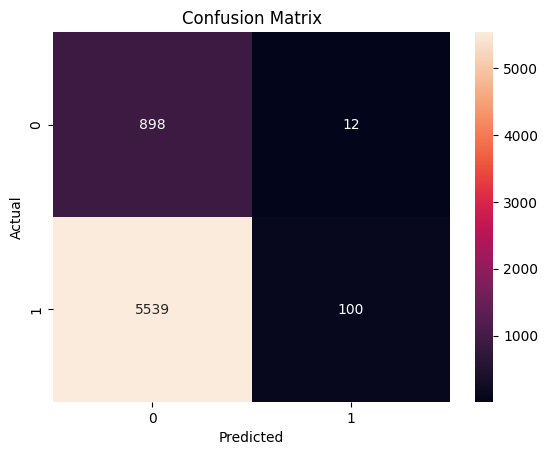

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
df.to_csv("/content/drive/MyDrive/final_results.csv", index=False)

In [ ]:
import cv2
import os

def extract_frames(video_path, output_folder, num_frames=8):
    os.makedirs(output_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return

    frame_idxs = [int(i * total_frames / num_frames) for i in range(num_frames)]

    count = 0
    saved = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if count in frame_idxs:
            cv2.imwrite(f"{output_folder}/frame_{saved}.jpg", frame)
            saved += 1

        count += 1

    cap.release()

In [ ]:
import numpy as np
from PIL import Image

def predict_frames(frames_folder):
    images = []

    for img_name in os.listdir(frames_folder):
        img_path = os.path.join(frames_folder, img_name)
        img = Image.open(img_path).convert('RGB')
        images.append(transform(img))

    if len(images) == 0:
        return 0.5  # fallback

    batch = torch.stack(images).to(device)

    with torch.no_grad():
        outputs = model(batch)
        probs = torch.softmax(outputs, dim=1)

        # IMPORTANT: use REAL class probability (class index 1)
        real_probs = probs[:, 1].cpu().numpy()

    # SAME AS YOUR DATASET EVALUATION
    video_score = np.median(real_probs)

    return video_score

In [ ]:
def predict_video(video_path):
    import shutil

    temp_folder = "/content/temp_single_video"

    extract_frames(video_path, temp_folder, num_frames=8)

    score = predict_frames(temp_folder)

    shutil.rmtree(temp_folder)

    # FINAL DECISION (MATCH DATASET LOGIC)
    if score > 0.7:
        return "REAL", score
    else:
        return "FAKE", score

In [ ]:
video_path = "/content/CelebDF_v/Celeb-synthesis/id0_id16_0000.mp4"

result, score = predict_video(video_path)

print("Prediction:", result)
print("Score:", score)

Prediction: FAKE
Score: 0.5


In [ ]:
video_path = "/content/CelebDF_V/Celeb-real/id0_0000.mp4"

result, score = predict_video(video_path)

print("Prediction:", result)
print("Score:", score)

Prediction: REAL
Score: 0.7032676


In [ ]:
video_path = "/content/CelebDF_V/Celeb-synthesis/id0_id16_0006.mp4"

result, score = predict_video(video_path)

print("Prediction:", result)
print("Score:", score)

Prediction: FAKE
Score: 0.6684954


In [ ]:
video_path = "/content/CelebDF_V/Celeb-synthesis/id0_id20_0003.mp4"

result, score = predict_video(video_path)

print("Prediction:", result)
print("Score:", score)

Prediction: FAKE
Score: 0.56378317


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
video_path = list(uploaded.keys())[0]

In [ ]:
result = predict_video(video_path)

print("Prediction:", result)

Prediction: REAL
